In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
import GB84_eqs # import f as flux, rho_m
import updraft_emmanuel
import new_rainfall_scheme as nr
import top_outflow as outflow

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Loading the data

Choose the time interval for which the model is to be run.

In [2]:
#time to check
slice_str = "2024-07-19T00:00:00, 2024-07-19T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


Read the data which are to be used as inputs. The existing code uses a combined dataset from ERA5 surface values and ERA5 atmospheric profiles. The surface variables include the temperature, pressure, dew point temperature and vapor specific humidity and the profiles are of temperature,pressure and vapor specific humidity. Then, only the data corresponding to the desired time interval are selected.

In [3]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [4]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

The model inputs

In [5]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [6]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [7]:
rows = T_air.shape[0]
cols = T_air.shape[1]

Creating empty arrays (either of size (time,height) or (time)) for storing the model outputs. *temp_parcel* is the parcel temperature profile resulting by solving the thermodynamic equations implemented in the model, while *T_v_moist* and *q_v_parcel* are the resulting virtual temperature and moisture profiles of the parcel. *p_s*, *T_s* and *lcl_index* are the pressure, temperature and index at the LCL level. All the other arrays serve as the expansion of the current environmental profiles by 1 (time,height+1), so that the exact values of the meteorological variables at the LCL are stored. 

In [8]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


Implementing the model functions to calculate the temperature and humidity profiles.

1. Using the *profiles_and_cloud_heights.py*, the parcel temperature profile is calculated, as well as the LCL variables of interest.
2. Using the *interpolation_lcl.py*, all the parcel and environmental profiles are updated so that we have exact values for all the meteorological
   variables of interest at the LCL.
3. With *profiles_and_cloud_heights.py* parcel humidity and virtual temperature profiles are calculated. 

In [9]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'theta_l'       #choose which approach to follow for the conserved potential temperature

for i in range(0,T_air.shape[0]):
    #print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

Calculate the environmental virtual temperature profiles

In [10]:
T_v_env = my_temp_new*(1+0.61*q_v_new)  #no liquid water in the environmental air

### Cloud Heights

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [11]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

Finding the cloud top height and pressure and the resulting cloud depth, again by calling *profiles_and_cloud_heights.py*.

In [12]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel updraft velocity profile by calling the *updraft_emmanuel.py*. To do so, we have to first find the index of cloud top height. 

In [13]:
#import updraft_emmanuel

w_parcel_max = np.zeros(rows)

for i in range(0,rows):
    #print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(p_new[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],p_t[i],top_index)

[0.10536052 0.11778304]
[0.11778304]
[0.18232156 0.10536052 0.11778304]
[0.15415068 0.18232156 0.10536052 0.11778304]
[0.13353139 0.15415068 0.18232156 0.10536052 0.11778304]
[0.08701138 0.09531018 0.10536052 0.11778304 0.13353139 0.15415068
 0.18232156 0.10536052 0.11778304]
[0.02985296 0.03077166]
[0.02985296 0.03077166 0.0317487 ]
[0.02985296 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797
 0.08004271 0.08701138 0.09531018 0.10536052 0.11778304 0.13353139
 0.15415068 0.18232156 0.10536052 0.11778304]
[3.74787805e-05]
[0.0142372  0.02985296 0.03077166 0.0317487  0.03278982 0.06899287
 0.07410797 0.08004271 0.08701138 0.09531018 0.10536052 0.11778304
 0.13353139 0.15415068 0.18232156 0.10536052 0.11778304]
[0.00479966 0.02985296 0.03077166 0.0317487  0.03278982 0.06899287
 0.07410797 0.08004271 0.08701138 0.09531018 0.10536052 0.11778304
 0.13353139 0.15415068 0.18232156 0.10536052 0.11778304]
[0.00131208 0.02985296 0.03077166 0.0317487 ]
[0.00601815]
[0.02342073 0.02985296 0.0

### State calculation and update

Calculating the state evolution with time. The moisture flux in the cloud system is calculated using the *GB84.py* to find the amount of condensed water, while the outflow is consists of the water amount converted to rain (calculated by *autoconversion_rate.py*) and the cloud droplets caught by the updraft (*top_outflow.py*).

In [14]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = GB84_eqs.rho_m(T_s[i],my_temp_new[i,min(top_index,cols-1)],p_s[i],p_t[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = GB84_eqs.calculate_liquid_water_flux(T_d[i],p_new[i,0],p_t[i],my_temp_new[i,min(top_index,cols-1)],rho,w_avg)

    if i<rows-1:
        if X[i]/Z_c[i] > 2.5e-3:        #capping the LWC values so that they don't abnormally high
            X[i] = 2.5e-3*Z_c[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconoversion_rate(X[i],Z_c[i],thresh)*dt_seconds[i] - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])      #ensuring that the LWC is non-negative

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


#### Rainfall rates

Calculating the precipitation rate in the ground. First, the rate of rainfall exiting the cloud is found by calling *autoconversion_rate.py*. Then, given this rainfall rate, we assume and calculate (*new_rainfall_scheme.py*) a rain droplet size distribution and we estimate the amount that survives evaporation and reaches the ground as precipitation.

In [16]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.cloud_water_autoconoversion_rate(X[i],Z_c[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

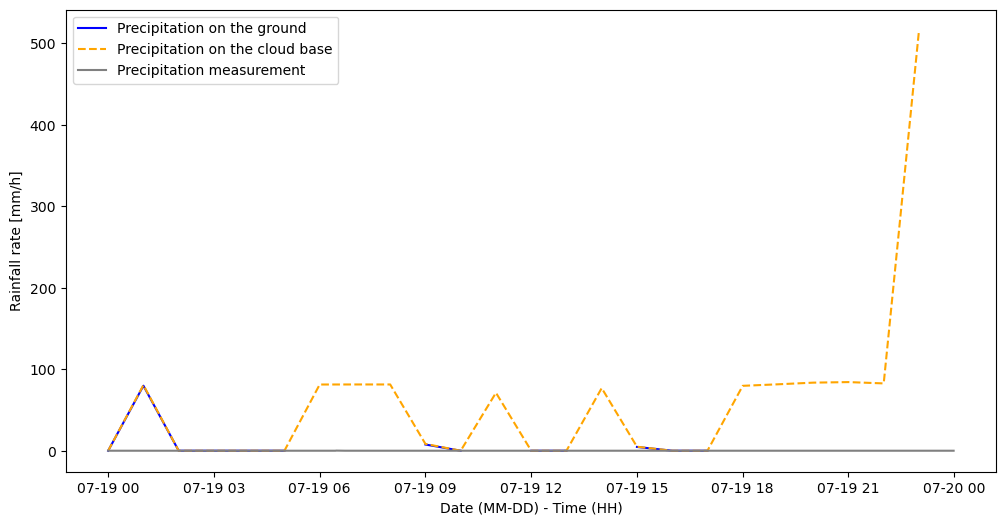

In [17]:
plt.figure(figsize=(12,6))
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

#### Virtual Temperature profiles at different times

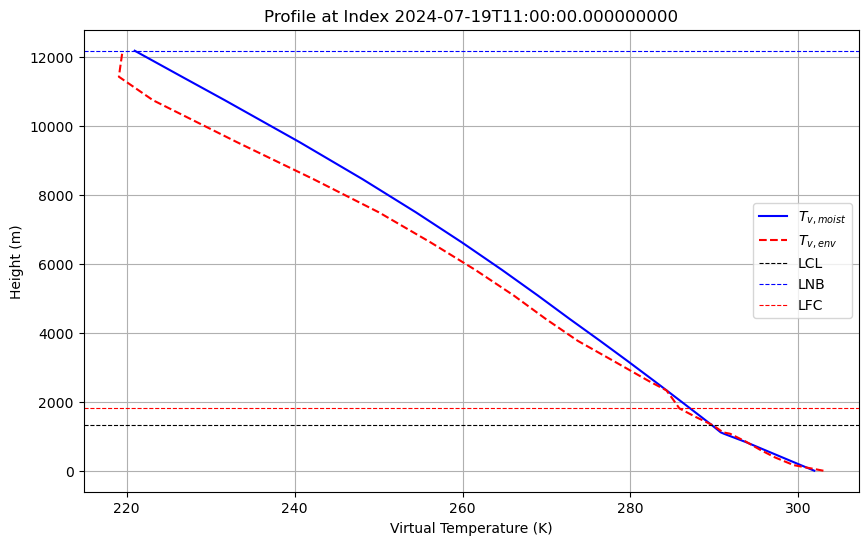

In [18]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[index_2,int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[index_2,int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

#### Cloud top and base

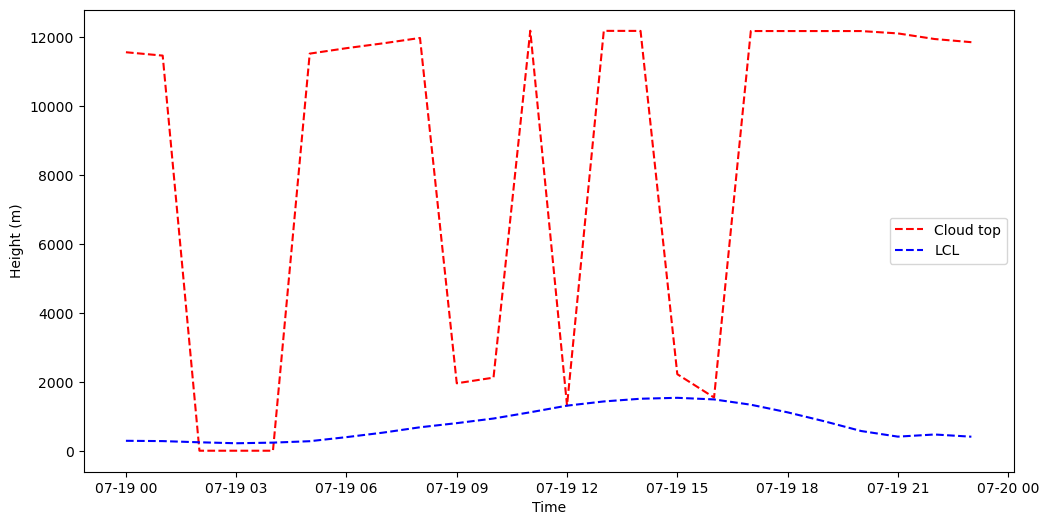

In [19]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Time')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

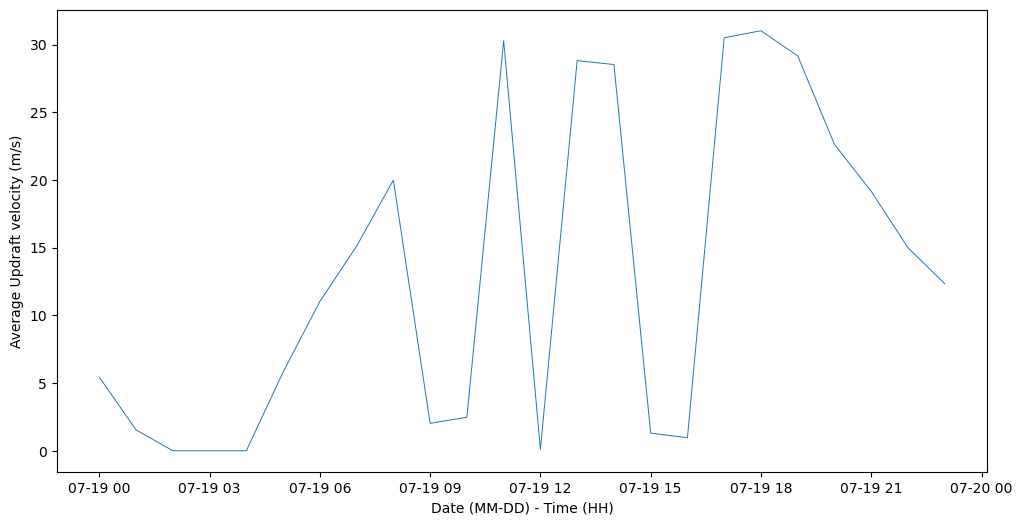

In [20]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

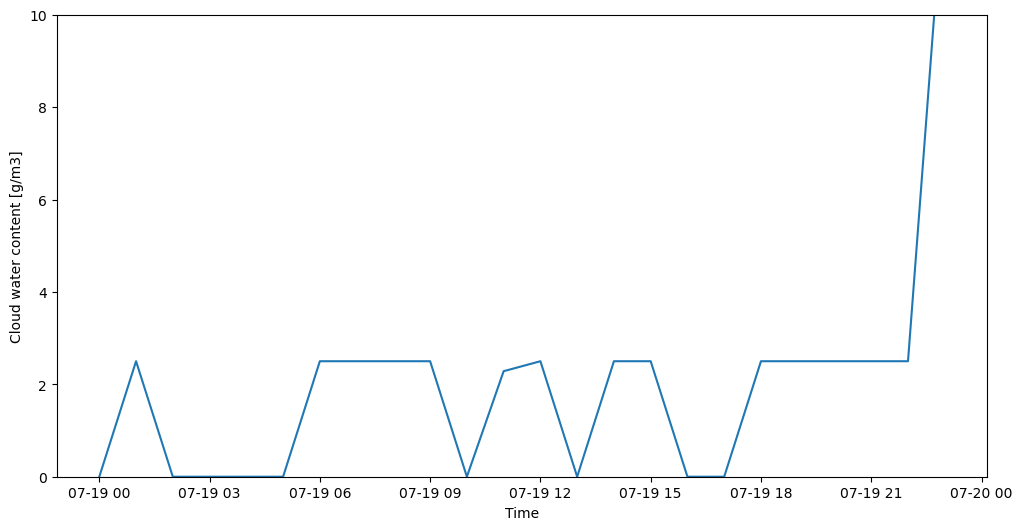

In [21]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

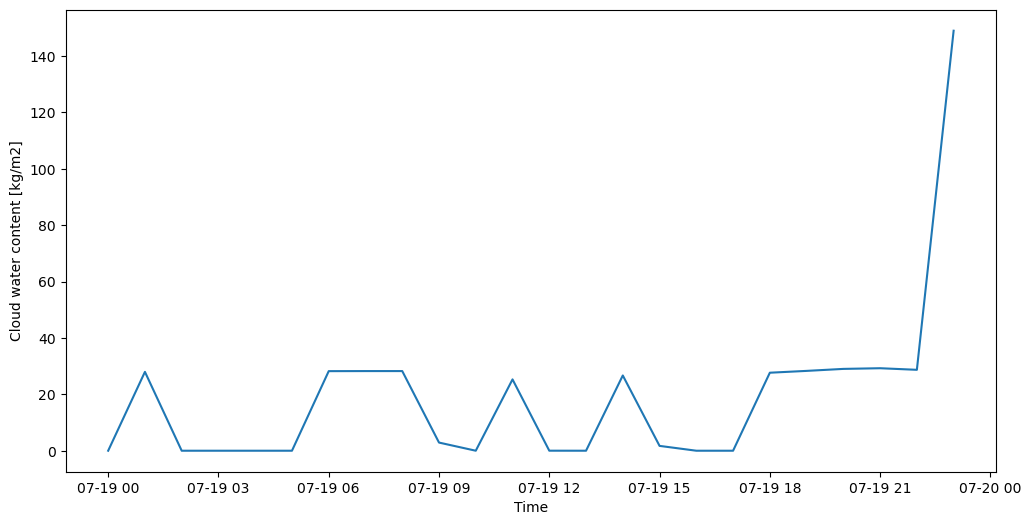

In [22]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

#### Size distribution

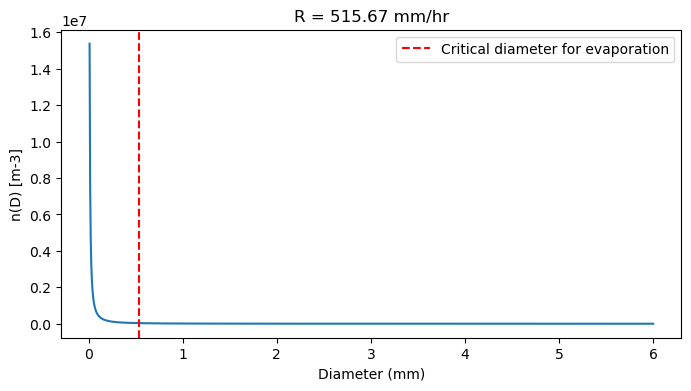

In [23]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()